In [5]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [6]:
data = pd.read_csv('studentdataset.csv')
data.head()

,Student ID,Socio-economic Status,School Type,Gender,Reading Score,Writing Score,Math Score,Science Score,Chosen Program
0,1,Low,Public,Female,75,80,65,70,Vocational
1,2,High,Private,Male,85,88,90,92,Academic
2,3,Medium,Public,Female,70,75,70,80,Vocational
3,4,High,Private,Male,90,92,95,96,Academic
4,5,Low,Public,Female,60,65,50,55,Vocational


In [7]:
data_copy = data.copy()

In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Student ID             100 non-null    int64 
 1   Socio-economic Status  100 non-null    object
 2   School Type            100 non-null    object
 3   Gender                 100 non-null    object
 4   Reading Score          100 non-null    int64 
 5   Writing Score          100 non-null    int64 
 6   Math Score             100 non-null    int64 
 7   Science Score          100 non-null    int64 
 8   Chosen Program         100 non-null    object
dtypes: int64(5), object(4)
memory usage: 7.2+ KB


In [44]:
clean_data = {
    'Socio-economic Status' : {'Low' : 0 , 'Medium' : 1 ,'High' : 2},
    'School Type' : { 'Public' : 0 ,'Private' : 1},
    'Gender' : { 'Male' : 0, 'Female' : 1},
    'Chosen Program' : { 'Vocational' : 0, 'Academic' :1}
}
data_copy.replace(clean_data,inplace =True)
print(data_copy)

    Student ID  Socio-economic Status  School Type  Gender  Reading Score  \
0            1                      0            0       1             75   
1            2                      2            1       0             85   
2            3                      1            0       1             70   
3            4                      2            1       0             90   
4            5                      0            0       1             60   
..         ...                    ...          ...     ...            ...   
95          96                      0            0       1             56   
96          97                      1            1       0             78   
97          98                      2            0       1             91   
98          99                      0            1       0             52   
99         100                      1            0       1             70   

    Writing Score  Math Score  Science Score  Chosen Program  
0           

In [10]:
data_copy.describe()

,Student ID,Socio-economic Status,School Type,Gender,Reading Score,Writing Score,Math Score,Science Score,Chosen Program
count,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.00000
mean,50.500000,0.990000,0.490000,0.510000,74.200000,76.270000,72.590000,74.940000,0.43000
std,29.011492,0.822598,0.502418,0.502418,14.400477,13.674318,16.884692,16.290184,0.49757
min,1.000000,0.000000,0.000000,0.000000,50.000000,53.000000,45.000000,50.000000,0.00000
25%,25.750000,0.000000,0.000000,0.000000,60.750000,63.750000,58.000000,60.000000,0.00000
50%,50.500000,1.000000,0.000000,1.000000,75.000000,78.000000,71.500000,74.000000,0.00000
75%,75.250000,2.000000,1.000000,1.000000,88.000000,89.250000,92.000000,93.000000,1.00000
max,100.000000,2.000000,1.000000,1.000000,97.000000,97.000000,98.000000,99.000000,1.00000


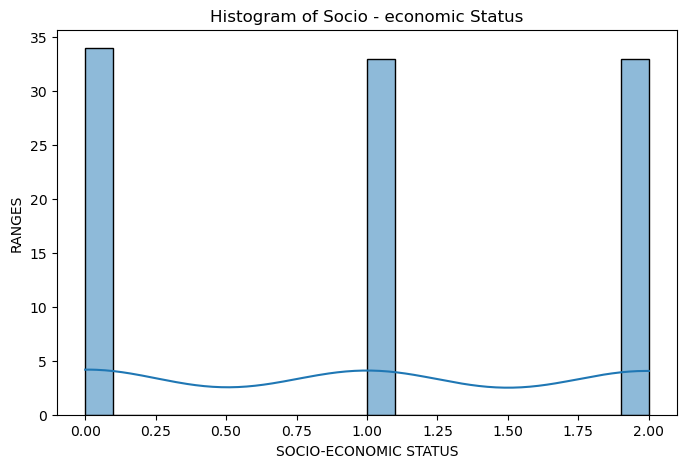

In [11]:
plt.figure(figsize = (8,5))
sns.histplot(data_copy['Socio-economic Status'] ,bins = 20 , kde = True)
plt.title("Histogram of Socio - economic Status")
plt.xlabel("SOCIO-ECONOMIC STATUS")
plt.ylabel("RANGES")
plt.show()

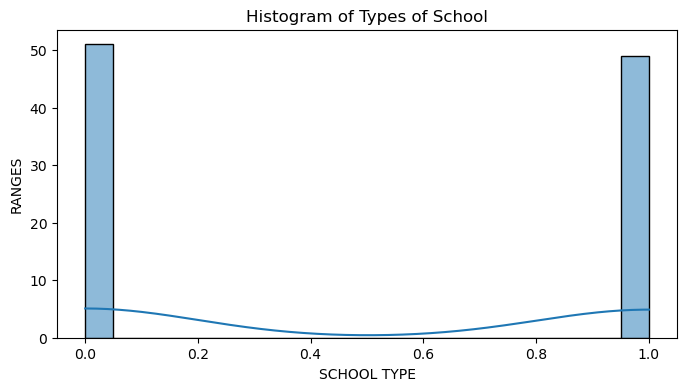

In [12]:
plt.figure(figsize = (8,4))
sns.histplot(data_copy['School Type'] ,bins = 20 , kde = True)
plt.title("Histogram of Types of School")
plt.xlabel("SCHOOL TYPE")
plt.ylabel("RANGES")
plt.show()

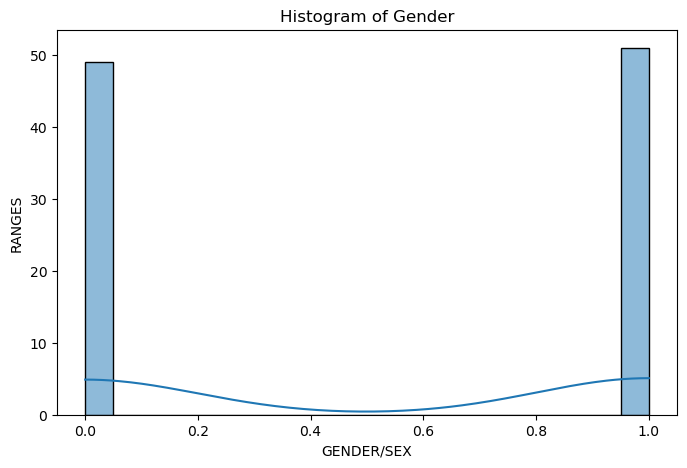

In [13]:
plt.figure(figsize = (8,5))
sns.histplot(data_copy['Gender'] ,bins = 20 , kde = True)
plt.title("Histogram of Gender")
plt.xlabel("GENDER/SEX")
plt.ylabel("RANGES")
plt.show()

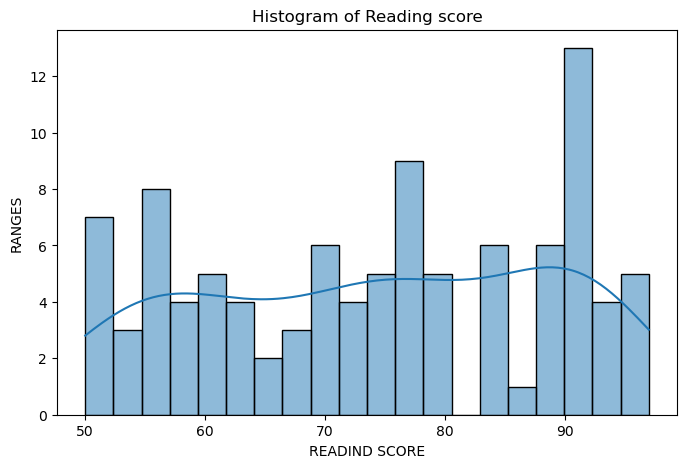

In [14]:
plt.figure(figsize = (8,5))
sns.histplot(data_copy['Reading Score'] ,bins = 20 , kde = True)
plt.title("Histogram of Reading score")
plt.xlabel("READIND SCORE")
plt.ylabel("RANGES")
plt.show()

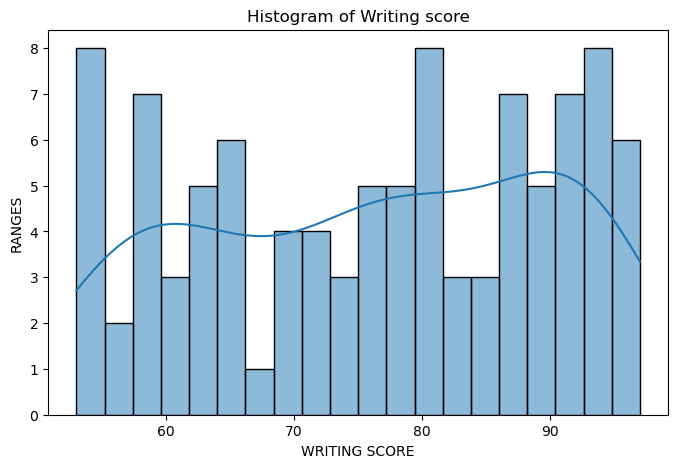

In [15]:
plt.figure(figsize = (8,5))
sns.histplot(data_copy['Writing Score'] ,bins = 20 , kde = True)
plt.title("Histogram of Writing score")
plt.xlabel("WRITING SCORE")
plt.ylabel("RANGES")
plt.show()

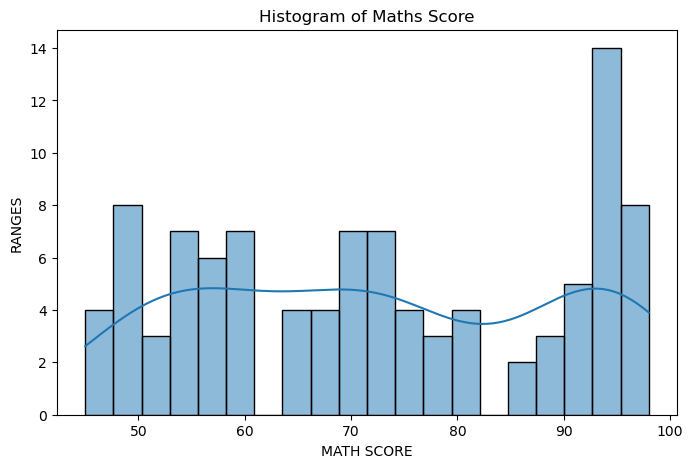

In [16]:
plt.figure(figsize = (8,5))
sns.histplot(data_copy['Math Score'] ,bins = 20 , kde = True)
plt.title("Histogram of Maths Score")
plt.xlabel("MATH SCORE")
plt.ylabel("RANGES")
plt.show()

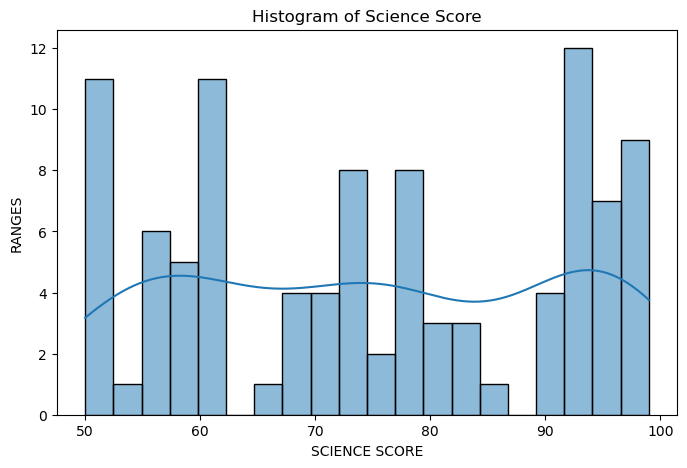

In [17]:
plt.figure(figsize = (8,5))
sns.histplot(data_copy['Science Score'] ,bins = 20 , kde = True)
plt.title("Histogram of Science Score")
plt.xlabel("SCIENCE SCORE")
plt.ylabel("RANGES")
plt.show()

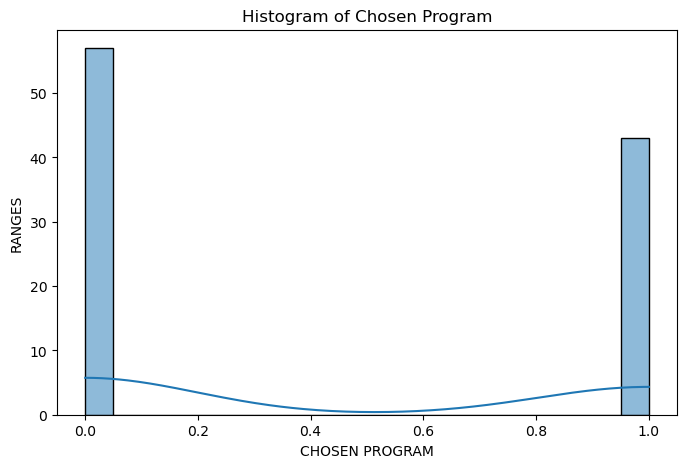

In [18]:
plt.figure(figsize = (8,5))
sns.histplot(data_copy['Chosen Program'] ,bins = 20 , kde = True)
plt.title("Histogram of Chosen Program")
plt.xlabel("CHOSEN PROGRAM")
plt.ylabel("RANGES")
plt.show()

In [19]:
print("CHECKING MISSING VALUES")
miss_val = data_copy.isnull().sum()
print("Missing values in each column : " )
print(miss_val)

CHECKING MISSING VALUES
Missing values in each column : 
Student ID               0
Socio-economic Status    0
School Type              0
Gender                   0
Reading Score            0
Writing Score            0
Math Score               0
Science Score            0
Chosen Program           0
dtype: int64


Checking Outliers Using Box Plot


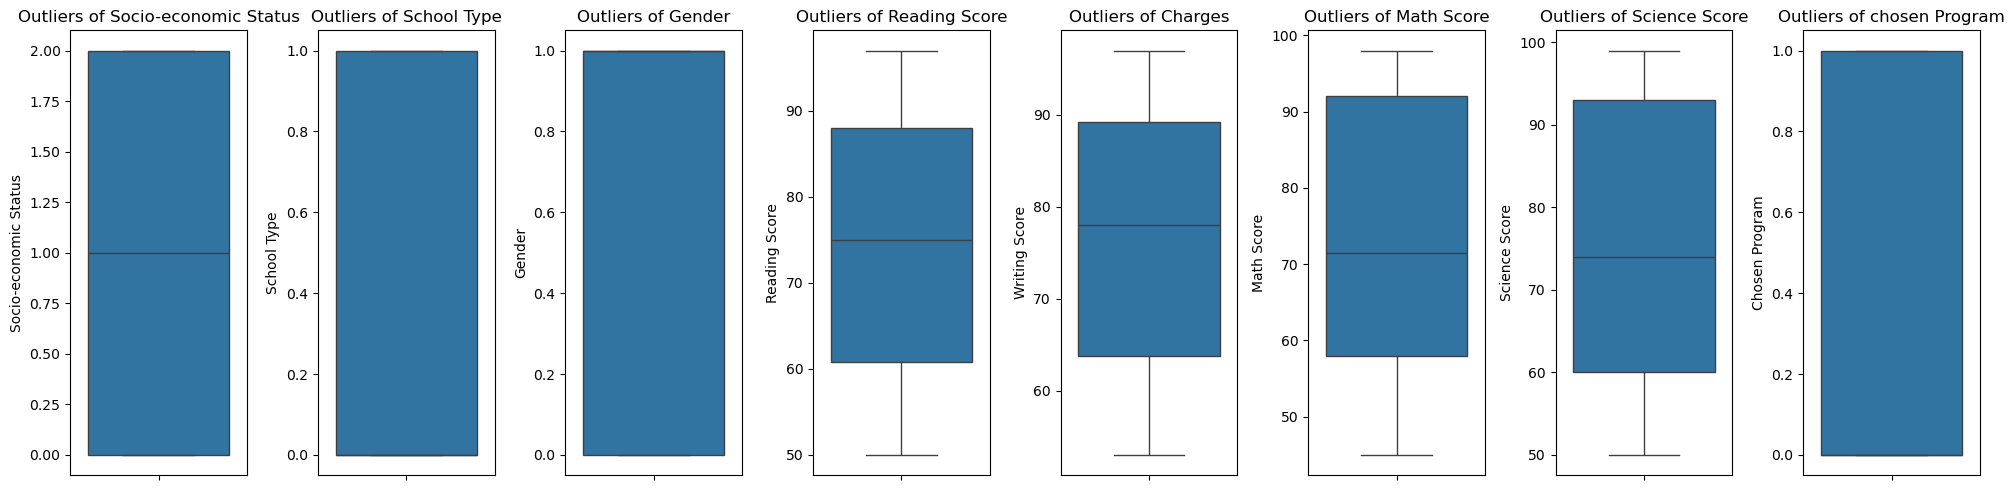

In [20]:
print("Checking Outliers Using Box Plot")
plt.figure(figsize = (20,5))
plt.subplot(1,8,1)
sns.boxplot( y = data_copy['Socio-economic Status'])
plt.title("Outliers of Socio-economic Status")

plt.subplot(1,8,2)
sns.boxplot(y = data_copy['School Type'])
plt.title("Outliers of School Type")

plt.subplot(1,8,3)
sns.boxplot(y = data_copy['Gender'])
plt.title("Outliers of Gender") 

plt.subplot(1,8,4)
sns.boxplot(y = data_copy['Reading Score'])
plt.title("Outliers of Reading Score")

plt.subplot(1,8,5)
sns.boxplot(y = data_copy['Writing Score'])
plt.title("Outliers of Charges")

plt.subplot(1,8,6)
sns.boxplot(y = data_copy['Math Score'])
plt.title("Outliers of Math Score")

plt.subplot(1,8,7)
sns.boxplot(y = data_copy['Science Score'])
plt.title("Outliers of Science Score")

plt.subplot(1,8,8)
sns.boxplot(y = data_copy['Chosen Program'])
plt.title("Outliers of chosen Program")

plt.tight_layout()
plt.show()

In [21]:
numerical_cols = ['Socio-economic Status', 'School Type','Gender','Reading Score','Writing Score', 'Math Score','Science Score']

for column in numerical_cols:
    Q1 = data_copy[column].quantile(0.25)
    Q3 = data_copy[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = data_copy[(data_copy[column] < lower_bound) | 
                        (data_copy[column] > upper_bound)][column]
    
    print(f"\nOutliers in {column}:")
    print(f"Number of outliers: {len(outliers)}")
    print(f"Percentage of outliers: {(len(outliers)/len(data_copy)*100):.2f}%")
    print(f"Outlier range: {outliers.min():.2f} to {outliers.max():.2f}")


Outliers in Socio-economic Status:
Number of outliers: 0
Percentage of outliers: 0.00%
Outlier range: nan to nan

Outliers in School Type:
Number of outliers: 0
Percentage of outliers: 0.00%
Outlier range: nan to nan

Outliers in Gender:
Number of outliers: 0
Percentage of outliers: 0.00%
Outlier range: nan to nan

Outliers in Reading Score:
Number of outliers: 0
Percentage of outliers: 0.00%
Outlier range: nan to nan

Outliers in Writing Score:
Number of outliers: 0
Percentage of outliers: 0.00%
Outlier range: nan to nan

Outliers in Math Score:
Number of outliers: 0
Percentage of outliers: 0.00%
Outlier range: nan to nan

Outliers in Science Score:
Number of outliers: 0
Percentage of outliers: 0.00%
Outlier range: nan to nan


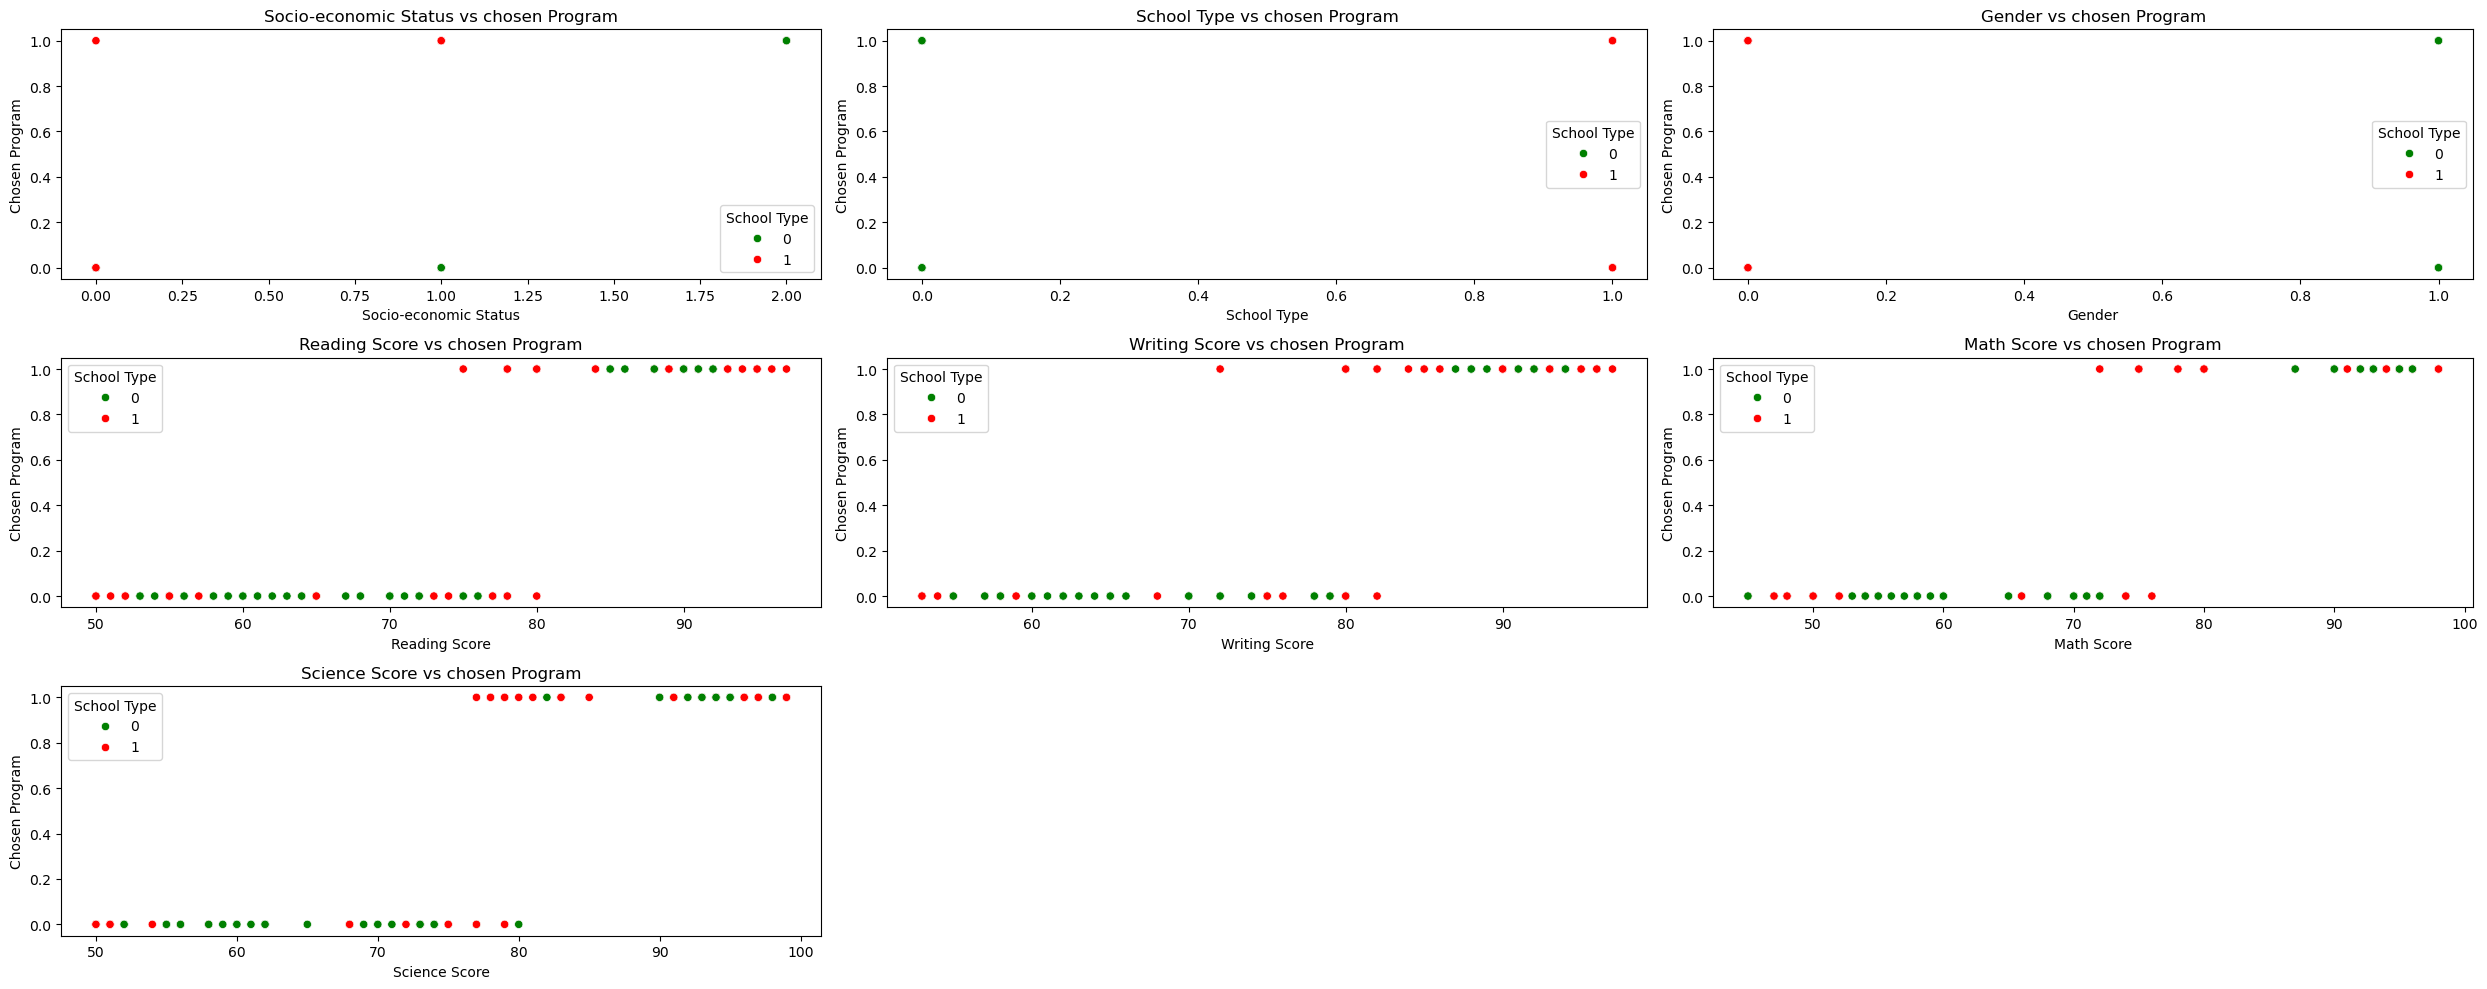

In [22]:
plt.figure(figsize=(25, 10))

plt.subplot(3, 3, 1)
sns.scatterplot(data=data_copy, x='Socio-economic Status', y='Chosen Program', 
                hue='School Type', palette=['green', 'red'])
plt.title('Socio-economic Status vs chosen Program')

plt.subplot(3, 3, 2)
sns.scatterplot(data=data_copy, x='School Type', y='Chosen Program', 
                hue='School Type', palette=['green', 'red'])
plt.title('School Type vs chosen Program')

plt.subplot(3, 3, 3)
sns.scatterplot(data=data_copy, x='Gender', y='Chosen Program', 
                hue='School Type', palette=['green', 'red'])
plt.title('Gender vs chosen Program')


plt.subplot(3, 3, 4)
sns.scatterplot(data=data_copy, x='Reading Score', y='Chosen Program', 
                hue='School Type', palette=['green', 'red'])
plt.title('Reading Score vs chosen Program')

plt.subplot(3, 3, 5)
sns.scatterplot(data=data_copy, x='Writing Score', y='Chosen Program', 
                hue='School Type', palette=['green', 'red'])
plt.title('Writing Score vs chosen Program')

plt.subplot(3, 3, 6)
sns.scatterplot(data=data_copy, x='Math Score', y='Chosen Program', 
                hue='School Type', palette=['green', 'red'])
plt.title('Math Score vs chosen Program')

plt.subplot(3, 3, 7)
sns.scatterplot(data=data_copy, x='Science Score', y='Chosen Program', 
                hue='School Type', palette=['green', 'red'])
plt.title('Science Score vs chosen Program')

plt.tight_layout()
plt.show()

In [23]:
X = data_copy[['Socio-economic Status', 'School Type', 'Gender', 'Reading Score', 'Writing Score', 'Math Score', 'Science Score']]
y = data_copy['Chosen Program']

new_data = pd.DataFrame(data_copy[['Socio-economic Status', 'School Type', 'Gender', 'Reading Score', 'Writing Score', 'Math Score', 'Science Score']])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


linear_model = LinearRegression()
linear_model.fit(X_train_scaled, y_train)

y_pred = linear_model.predict(X_test_scaled)
y_pred_rounded = [round(value) for value in y_pred]

print("Mean Squared Error:", mean_squared_error(y_test, y_pred))
print("R-squared:", r2_score(y_test, y_pred))

from sklearn.metrics import accuracy_score, classification_report
print("Accuracy:", accuracy_score(y_test, y_pred_rounded))
print("Classification Report:\n", classification_report(y_test, y_pred_rounded))

new_data_scaled = scaler.transform(new_data)  
predicted_program = linear_model.predict(new_data_scaled)
program_mapping = {0: 'Vocational', 1: 'Academic'}
predicted_program_rounded = round(predicted_program[0]) 
print("Predicted Program:", program_mapping[predicted_program_rounded])

Mean Squared Error: 0.05667172499059301
R-squared: 0.7710233333713414
Accuracy: 0.9
Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.91      0.91        11
           1       0.89      0.89      0.89         9

    accuracy                           0.90        20
   macro avg       0.90      0.90      0.90        20
weighted avg       0.90      0.90      0.90        20

Predicted Program: Vocational
